# Jacobians Around a Distorted FODO Lattice

**Notebook 02 — educational exercise**

Notebook 01 compared three Jacobian methods around the nominal lattice. Here the lattice already contains known quadrupole errors.

Main question:

> Do the numerical and analytical Jacobians still agree when they are evaluated around the same distorted lattice?

This is not yet a full LOCO fit.

## Learning objectives

You will:

1. create a distorted FODO lattice,
2. compare its ORM with the nominal ORM,
3. calculate Jacobians around the distorted lattice,
4. keep \(K\), \(KL\), kick normalization, ordering, and signs explicit,
5. decide whether the three methods still agree.

Cells marked **STUDENT TASK — YOUR CODE HERE** intentionally contain no solution.

In [1]:
%matplotlib inline

import copy
import time
from tempfile import TemporaryDirectory

import at
import matplotlib.pyplot as plt
import numpy as np

from analytic_orm_with_normal_quad_errors import (
    analytic_orm_variation_with_normal_quadrupole,
)
from pyLOCO.analysis import plot_matrices
from pyLOCO.config import FitInitConfig, RMConfig
from pyLOCO.pyloco import calculate_quads_jacobian
from pyLOCO.response_matrix import response_matrix

## 1. Nominal FODO and measurement convention — PROVIDED CODE

The lattice, BPM/corrector order, and \(10^{-5}\,\mathrm{rad}\) kick are identical to Notebook 01.

In [2]:
# PROVIDED CODE
QF = at.Quadrupole("QF", 0.5, 1.2)
QD = at.Quadrupole("QD", 0.5, -1.2)
Dr, HalfDr = at.Drift("Dr", 0.5), at.Drift("Dr", 0.25)
Bend = at.Dipole("Bend", 1.0, 2*np.pi/40)
cell = at.Lattice([
    HalfDr, Bend, Dr, at.Monitor("BPM_F"),
    at.Corrector("HCOR_F", 0, [0, 0]), at.Corrector("VCOR_F", 0, [0, 0]), QF,
    Dr, Bend, Dr, at.Monitor("BPM_D"),
    at.Corrector("HCOR_D", 0, [0, 0]), at.Corrector("VCOR_D", 0, [0, 0]), QD, HalfDr,
], name="Simple FODO cell with diagnostics", energy=1e9)
nominal_ring = cell * 20

bpm_indices = np.asarray(at.get_refpts(nominal_ring, at.Monitor), int)
hcor_indices = np.asarray(at.get_refpts(nominal_ring, "HCOR*"), int)
vcor_indices = np.asarray(at.get_refpts(nominal_ring, "VCOR*"), int)
quad_indices = np.asarray(at.get_refpts(nominal_ring, at.Quadrupole), int)
n_bpm, n_hcor, n_vcor = len(bpm_indices), len(hcor_indices), len(vcor_indices)

corrector_kick_rad = 1e-5
kick_steps = [[corrector_kick_rad]*n_hcor, [corrector_kick_rad]*n_vcor]
rm_config = RMConfig(
    bpm_ords=bpm_indices, cm_ords=[hcor_indices, vcor_indices],
    dkick=kick_steps, calculator="Linear", includeDispersion=False,
    HCMCoupling=np.zeros(n_hcor), VCMCoupling=np.zeros(n_vcor),
)
R_nominal_displacement = response_matrix(nominal_ring, config=rm_config)
R_nominal = R_nominal_displacement / corrector_kick_rad
print("Counts BPM/H/V/Q:", n_bpm, n_hcor, n_vcor, len(quad_indices))
print("R_nominal shape:", R_nominal.shape)

Counts BPM/H/V/Q: 40 40 40 40
R_nominal shape: (80, 80)


## 2. Assign known quadrupole errors — PROVIDED CODE

Two quadrupoles receive small, known changes in \(K\). The distorted lattice is copied from the nominal lattice.

QF 6 assigned dK=+1.200000e-02 m^-2
QD 88 assigned dK=-9.000000e-03 m^-2
Distorted ORM RMS difference [m/rad]: 0.15935121101272323


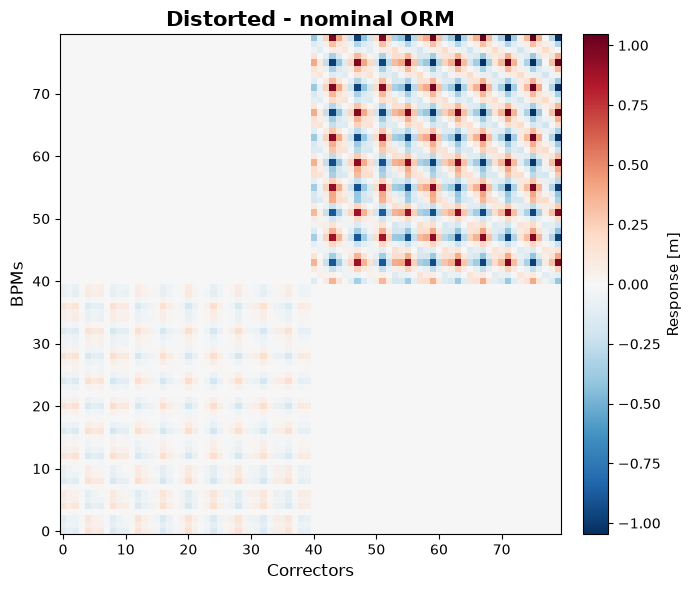

In [3]:
# PROVIDED CODE
distorted_ring = copy.deepcopy(nominal_ring)
error_positions = np.asarray([0, 11], dtype=int)
error_indices = quad_indices[error_positions]
assigned_delta_K = np.asarray([+0.012, -0.009])  # m^-2

for qidx, delta in zip(error_indices, assigned_delta_K):
    element = distorted_ring[int(qidx)]
    new_K = float(element.PolynomB[1]) + float(delta)
    element.PolynomB[1] = new_K
    element.K = new_K
    print(element.FamName, int(qidx), f"assigned dK={delta:+.6e} m^-2")

R_distorted_displacement = response_matrix(distorted_ring, config=rm_config)
R_distorted = R_distorted_displacement / corrector_kick_rad
delta_R = R_distorted - R_nominal
print("Distorted ORM RMS difference [m/rad]:", np.sqrt(np.mean(delta_R**2)))
plot_matrices(delta_R, titles=["Distorted - nominal ORM"], cmap="RdBu_r", plot_type="2d")

## 3. The evaluation point matters

A Jacobian is local:

$$J(K)=\frac{\partial R}{\partial K}\bigg|_{K}$$

Notebook 01 used the nominal strengths. This notebook evaluates every method at the distorted strengths. Comparing Jacobians evaluated at different lattices would not be a valid test.

## 4. Student Task 1 — Central Jacobian around the distorted lattice

Use every normal quadrupole as a fitted parameter. Start each perturbation from `distorted_ring`, not `nominal_ring`.

In [4]:
# ==========================================================
# STUDENT TASK 1 — YOUR CODE HERE
# ==========================================================
n_measurements = R_distorted.size
n_quads = len(quad_indices)
J_student_distorted = np.zeros((n_measurements, n_quads))
student_jacobian_complete = False

for j, qidx in enumerate(quad_indices):
    # Read K0 from distorted_ring.
    # Choose dK = 1e-3*abs(K0).
    # Calculate normalized R_plus and R_minus.
    # Use the central difference.
    # Flatten with order="F" and store column j.
    # Restore nothing by hand: use independent lattice copies.
    #
    # YOUR CODE HERE
    pass

# student_jacobian_complete = True
print("Target shape:", J_student_distorted.shape)
print("Task complete:", student_jacobian_complete)

Target shape: (6400, 40)
Task complete: False


## 5. pyLOCO numerical Jacobian around the distorted lattice — PROVIDED CODE

pyLOCO uses a forward difference in \(K=\mathrm{PolynomB}[1]\). Its ORM calculator remains `Linear`.

In [5]:
# PROVIDED CODE
fit_config = FitInitConfig(
    fit_list=["quads"], CMstep=kick_steps, individuals=True,
    quads_attr="PolynomB", quads_attr_index=1,
)
with TemporaryDirectory(prefix="fodo_distorted_pyloco_") as output:
    blocks, pyloco_steps = calculate_quads_jacobian(
        distorted_ring, R_distorted_displacement, kick_steps,
        [hcor_indices, vcor_indices], bpm_indices, quad_indices,
        None, np.eye(2*n_bpm), True,
        np.zeros(n_hcor), np.zeros(n_vcor), -3000.0, "quads",
        auto_correct_delta=False, fit_cfg=fit_config,
        output_dir=output, processes=1, includeDispersion=False,
    )
J_pyloco_distorted = np.column_stack(
    [block.ravel(order="F") for block in blocks]
) / corrector_kick_rad
print("J_pyloco_distorted shape:", J_pyloco_distorted.shape)

J_pyloco_distorted shape: (6400, 40)


## 6. ESRF analytical Jacobian around the distorted lattice — PROVIDED CODE

The ESRF output is with respect to \(KL\). Convert it without fitting a scale:

$$\frac{\partial R}{\partial K}=L\,\frac{\partial R}{\partial(KL)}$$

In [6]:
# PROVIDED CODE
start = time.perf_counter()
dMH_dKL, dMV_dKL = analytic_orm_variation_with_normal_quadrupole(
    distorted_ring, ind_bpms=bpm_indices, ind_cors=hcor_indices,
    ind_quads=quad_indices, thick_quadrupole=True,
    thick_steerers=False, verbose=False, use_mp=False,
)
analytical_time = time.perf_counter() - start

columns = []
for j, qidx in enumerate(quad_indices):
    matrix = np.zeros_like(R_distorted)
    length = distorted_ring[int(qidx)].Length
    matrix[:n_bpm, :n_hcor] = -dMH_dKL[:, :, j] * length
    matrix[n_bpm:, n_hcor:] = +dMV_dKL[:, :, j] * length
    columns.append(matrix.ravel(order="F"))
J_analytical_distorted = np.column_stack(columns)
print("J_analytical_distorted shape:", J_analytical_distorted.shape)
print(f"Analytical time: {analytical_time:.3f} s")

J_analytical_distorted shape: (6400, 40)
Analytical time: 4.515 s


## 7. Student Task 2 — Three-way validation

Calculate max absolute, RMS, and relative norm differences. Report full-matrix results and separate \(R_{xx}\) and \(R_{yy}\) results. Do not rescale any matrix.

In [7]:
# ==========================================================
# STUDENT TASK 2 — YOUR CODE HERE
# ==========================================================
if not student_jacobian_complete:
    print("Complete Student Task 1 first.")
else:
    # Compare:
    # J_student_distorted vs J_pyloco_distorted
    # J_student_distorted vs J_analytical_distorted
    # J_pyloco_distorted vs J_analytical_distorted
    #
    # YOUR CODE HERE
    pass

Complete Student Task 1 first.


## 8. Questions

1. Did agreement improve or worsen compared with the nominal lattice?
2. Were all three methods evaluated at exactly the same strengths?
3. Which discrepancy is caused by forward versus central difference?
4. Does the K/KL conversion depend on quadrupole length?
5. Are discrepancies larger for focusing or defocusing quadrupoles?
6. Are cross-plane blocks still approximately zero?
7. Does a known lattice error change the parameter ordering?
8. What must be understood before an analytical Jacobian enters an iterative fit?

## 9. Student conclusions

### Distorted lattice
I assigned ...

### Numerical comparison
...

### Analytical comparison
...

### Differences from Notebook 01
...

### Questions for the iterative fit
...

## 10. Next step

Notebook 03 studies the iterative LOCO workflow. It also identifies what pyLOCO must expose so an analytical Jacobian can be recalculated at every iteration.